In [1]:
!pip install -q "transformers>=4.40.0" datasets peft accelerate bitsandbytes tqdm



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.4/59.4 MB 32.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.7/47.7 MB 41.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 112.8 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 76.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 46.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 34.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 14.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 3.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━

In [2]:
!pip install evaluate bert-score sentence-transformers


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 4.3 MB/s eta 0:00:00


In [3]:
import os
if "COLAB_GPU" in os.environ:
  from google.colab import output
  output.enable_custom_widget_manager()

In [ ]:
import os
from huggingface_hub import notebook_login

# If running in Google Colab
if "COLAB_GPU" in os.environ:
    !huggingface-cli login
# If running locally (Jupyter, VS Code, etc.)
else:
    notebook_login()


In [5]:
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel
import torch

model_name = "google/gemma-3-1b-it"
adapter_name = "ZunairAhmad/gemma3-mental-health"

device = "cuda" if torch.cuda.is_available() else "cpu"

tokenizer = AutoTokenizer.from_pretrained(model_name)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

base = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.bfloat16,
    device_map="auto"
)

model = PeftModel.from_pretrained(base, adapter_name)
model.eval()


2025-12-06 12:48:52.629941: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765025332.825723      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765025332.886951      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

...

generation_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

adapter_config.json: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.11/dist-packages/peft/config.py:165: UserWarning: Unexpected keyword arguments ['alora_invocation_tokens', 'arrow_config', 'ensure_weight_tying', 'peft_version', 'target_parameters'] for class LoraConfig, these are ignored. This probably means that you're loading a configuration file that was saved using a higher version of the library and additional parameters have been introduced since. It is highly recommended to upgrade the PEFT version before continuing (e.g. by running `pip install -U peft`).
  warnings.warn(


adapter_model.safetensors:   0%|          | 0.00/52.2M [00:00<?, ?B/s]

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): Gemma3ForCausalLM(
      (model): Gemma3TextModel(
        (embed_tokens): Gemma3TextScaledWordEmbedding(262144, 1152, padding_idx=0)
        (layers): ModuleList(
          (0-25): 26 x Gemma3DecoderLayer(
            (self_attn): Gemma3Attention(
              (q_proj): lora.Linear(
                (base_layer): Linear(in_features=1152, out_features=1024, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.1, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=1152, out_features=16, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=16, out_features=1024, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
         

In [6]:
from datasets import load_dataset

ds = load_dataset("Amod/mental_health_counseling_conversations")
split = ds["train"].train_test_split(test_size=0.30, seed=42)
test_ds = split["test"]

print(len(test_ds), "evaluation samples loaded")


README.md: 0.00B [00:00, ?B/s]

combined_dataset.json: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/3512 [00:00<?, ? examples/s]

1054 evaluation samples loaded


**Generation function**

In [ ]:
import torch
torch._dynamo.config.suppress_errors = True
torch._dynamo.disable()

def generate_response(context, max_new_tokens=128):
    
    messages = [
        {
            "role": "user",
            "content": [{"type": "text", "text": f"Context: {context}"}]
        }
    ]

    inputs = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt=True,
        return_tensors="pt"
    ).to(model.device)

    with torch.no_grad():
        output_ids = model.generate(
            input_ids=inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=0.7,
            top_p=0.9,
            pad_token_id=tokenizer.eos_token_id,
            use_cache=False   
        )

    decoded = tokenizer.decode(output_ids[0], skip_special_tokens=True)

    if "assistant" in decoded.lower():
        decoded = decoded.split("assistant", 1)[-1]

    return decoded.strip()


**Generate predictions for evaluation**

In [10]:
from tqdm.auto import tqdm

preds = []
refs = []

for sample in tqdm(test_ds, desc="Generating model responses", colour="green"):
    context = sample["Context"]
    reference = sample["Response"]

    prediction = generate_response(context)

    preds.append(prediction)
    refs.append(reference)


Generating model responses:   0%|          | 0/1054 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['cache_implementation']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['cache_implementation']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['cache_implementation']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['cache_implementation']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['cache_implementation']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['cache_implementation']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['cache_implementation']. Set `TRANSFORMERS_VERBOSITY=info` for more details.

**ROUGE Score**

In [11]:
import evaluate

rouge = evaluate.load("rouge")
rouge_scores = rouge.compute(predictions=preds, references=refs)

print("ROUGE Scores:")
print(rouge_scores)


ROUGE Scores:
{'rouge1': 0.30598992650604495, 'rouge2': 0.049297602042847416, 'rougeL': 0.14286272973492858, 'rougeLsum': 0.1730294976977613}


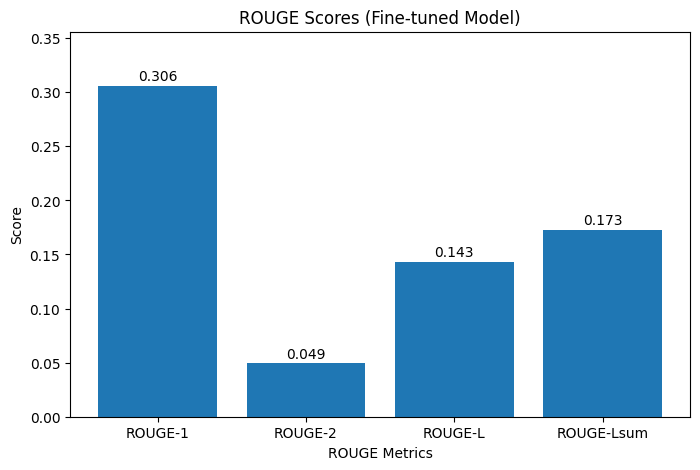

In [ ]:
import matplotlib.pyplot as plt


scores = {
    "ROUGE-1": rouge_scores["rouge1"],
    "ROUGE-2": rouge_scores["rouge2"],
    "ROUGE-L": rouge_scores["rougeL"],
    "ROUGE-Lsum": rouge_scores["rougeLsum"]
}

metrics = list(scores.keys())
values = list(scores.values())

plt.figure(figsize=(8, 5))
plt.bar(metrics, values)

plt.xlabel("ROUGE Metrics")
plt.ylabel("Score")
plt.title("ROUGE Scores (Fine-tuned Model)")
plt.ylim(0, max(values) + 0.05)

for i, v in enumerate(values):
    plt.text(i, v + 0.005, f"{v:.3f}", ha='center')

plt.show()


**BERTScore**

In [13]:
bertscore = evaluate.load("bertscore")
bert_scores = bertscore.compute(
    predictions=preds,
    references=refs,
    lang="en"
)

print("BERTScore F1:", sum(bert_scores["f1"])/len(bert_scores["f1"]))


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BERTScore F1: 0.8326255300239549


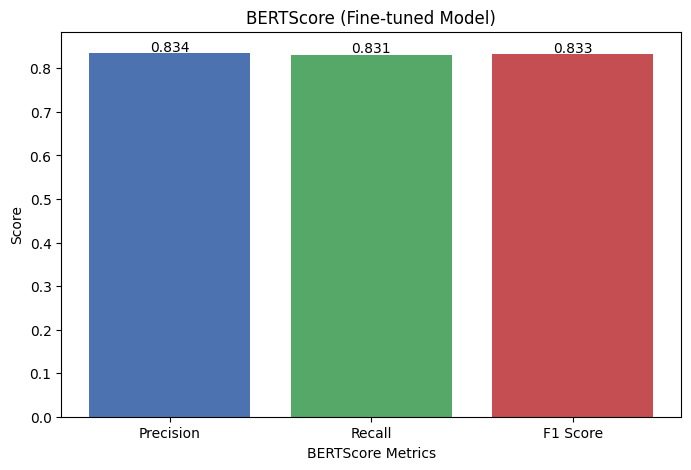

In [14]:
import matplotlib.pyplot as plt

# Extract average precision, recall, F1 from bert_scores
bert_p = sum(bert_scores["precision"]) / len(bert_scores["precision"])
bert_r = sum(bert_scores["recall"]) / len(bert_scores["recall"])
bert_f1 = sum(bert_scores["f1"]) / len(bert_scores["f1"])

metrics = ["Precision", "Recall", "F1 Score"]
values = [bert_p, bert_r, bert_f1]

plt.figure(figsize=(8, 5))
plt.bar(metrics, values, color=["#4C72B0", "#55A868", "#C44E52"])

plt.xlabel("BERTScore Metrics")
plt.ylabel("Score")
plt.title("BERTScore (Fine-tuned Model)")
plt.ylim(0, max(values) + 0.05)

# Add text labels on top of bars
for i, v in enumerate(values):
    plt.text(i, v + 0.005, f"{v:.3f}", ha='center')

plt.show()
